In [1]:
import torch
import torch.nn as nn
from torch.optim import SGD
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
import numpy as np
import matplotlib.pyplot as plt

# Data Base

In [2]:
def npy_loader(path):
    return torch.from_numpy(np.load(path))

In [3]:
BoldTrainDataImages = npy_loader("DataBase2\\BoldDataBase\\BoldTrainDataImages.npy")
BoldTrainDataLables = npy_loader("DataBase2\\BoldDataBase\\BoldTrainDataLables.npy")
BoldTestDataImages = npy_loader("DataBase2\\BoldDataBase\\BoldTestDataImages.npy")
BoldTestDataLables = npy_loader("DataBase2\\BoldDataBase\\BoldTestDataLables.npy")

### Labels

 - 0 = SetaBaixo;
 - 1 = SetaCima;
 - 2 = SetaEsquerda;
 - 3 = SetaDireita;
 - 4 = Circulo;
 - 5 = Coroa.

## Dataset Object

In [10]:
def npy_loader(path):
    return torch.from_numpy(np.load(path))

class CTDataset(Dataset):
    def __init__(self, filepathImg, filepathLables):
        self.x = npy_loader(filepathImg).to(torch.float32)
        self.y = npy_loader(filepathLables)
        self.x = self.x / 255.
        self.y = F.one_hot(self.y.to(torch.int64), num_classes=6).to(float)
    def __len__(self): 
        return self.x.shape[0]
    def __getitem__(self, ix): 
        return self.x[ix], self.y[ix]

In [11]:
BoldTrain_ds = CTDataset("DataBase2\\BoldDataBase\\BoldTrainDataImages.npy","DataBase2\\BoldDataBase\\BoldTrainDataLables.npy")
BoldTest_ds = CTDataset("DataBase2\\BoldDataBase\\BoldTestDataImages.npy","DataBase2\\BoldDataBase\\BoldTestDataLables.npy")

## Data Loader

In [13]:
BoldTrain_dl = DataLoader(BoldTrain_ds,batch_size=5)
for x, y in BoldTrain_dl:
    print(x.shape)
    print(y.shape)
    break

torch.Size([5, 28, 28])
torch.Size([5, 6])


### Cross Entropy Loss (Função calculo de erro)

In [14]:
L = nn.CrossEntropyLoss()

# A Rede

In [15]:
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,6,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.conv2 = nn.Conv2d(6,18,3)
        self.fc1 = nn.Linear(18*6*6,50)
        self.fc2 = nn.Linear(50,50)
        self.fc3 = nn.Linear(50,6)
        self.R = nn.ReLU()
    def forward(self,x):
        x = self.pool(self.R(self.conv1(x)))
        x = self.pool(self.R(self.conv2(x)))
        x = x.view(-1,18*6*6)
        x = self.R(self.fc1(x))
        x = self.R(self.fc2(x))
        x = self.fc3(x)
        return x.squeeze()

In [16]:
f = MyCNN()

## Treinamento

In [17]:
def train_model(dl, f, n_epochs=20):
    # Optimization
    opt = SGD(f.parameters(), lr=0.01)
    L = nn.CrossEntropyLoss()

    # Train model
    losses = []
    epochs = []
    for epoch in range(n_epochs):
        print(f'Epoch {epoch}')
        N = len(dl)
        for i, (x, y) in enumerate(dl):
            for j in range(len(x)):
                # Update the weights of the network
                opt.zero_grad() 
                loss_value = L(f(x[j].view(1,28,28)), y[j]) 
                loss_value.backward() 
                opt.step() 
                # Store training data
                epochs.append(epoch+i/N)
                losses.append(loss_value.item())
    return np.array(epochs), np.array(losses)

In [18]:
epoch_data, loss_data = train_model(BoldTrain_dl,f)

Epoch 0
Epoch 1
Epoch 2
Epoch 3
Epoch 4
Epoch 5
Epoch 6
Epoch 7
Epoch 8
Epoch 9
Epoch 10
Epoch 11
Epoch 12
Epoch 13
Epoch 14
Epoch 15
Epoch 16
Epoch 17
Epoch 18
Epoch 19


Text(0.5, 1.0, 'Cross Entropy (per batch)')

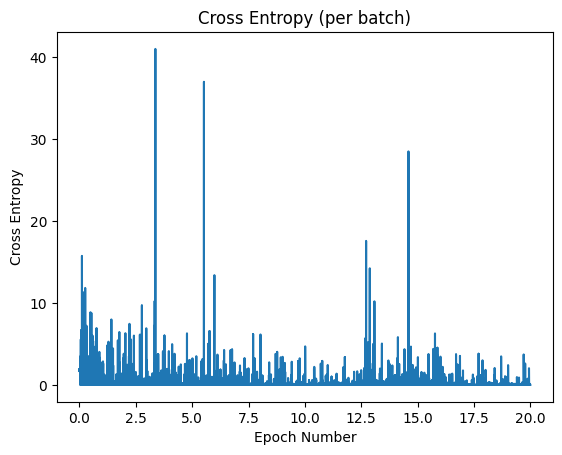

In [19]:
plt.plot(epoch_data, loss_data)
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entropy')
plt.title('Cross Entropy (per batch)')

In [20]:
epoch_data_avgd = epoch_data.reshape(20,-1).mean(axis=1)
loss_data_avgd = loss_data.reshape(20,-1).mean(axis=1)

Text(0.5, 1.0, 'Cross Entropy (avgd per epoch)')

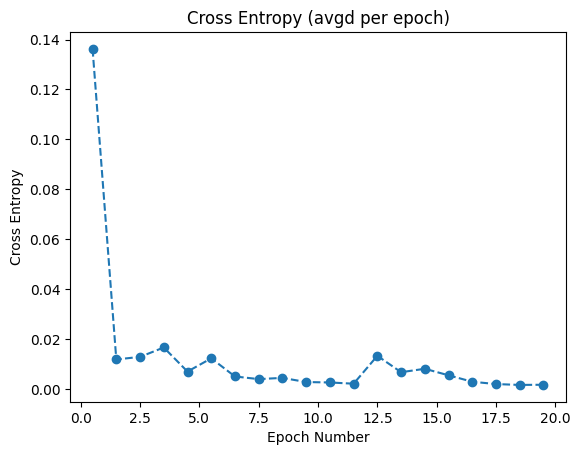

In [21]:
plt.plot(epoch_data_avgd, loss_data_avgd, 'o--')
plt.xlabel('Epoch Number')
plt.ylabel('Cross Entropy')
plt.title('Cross Entropy (avgd per epoch)')

In [24]:
xs, ys = BoldTest_ds[0:100]
yhats = np.zeros(shape=(100))
i=0
for each in xs:
    yhats[i] = f(each.view(1,28,28)).argmax().item()
    i += 1
ysArg = ys.argmax(axis=1)

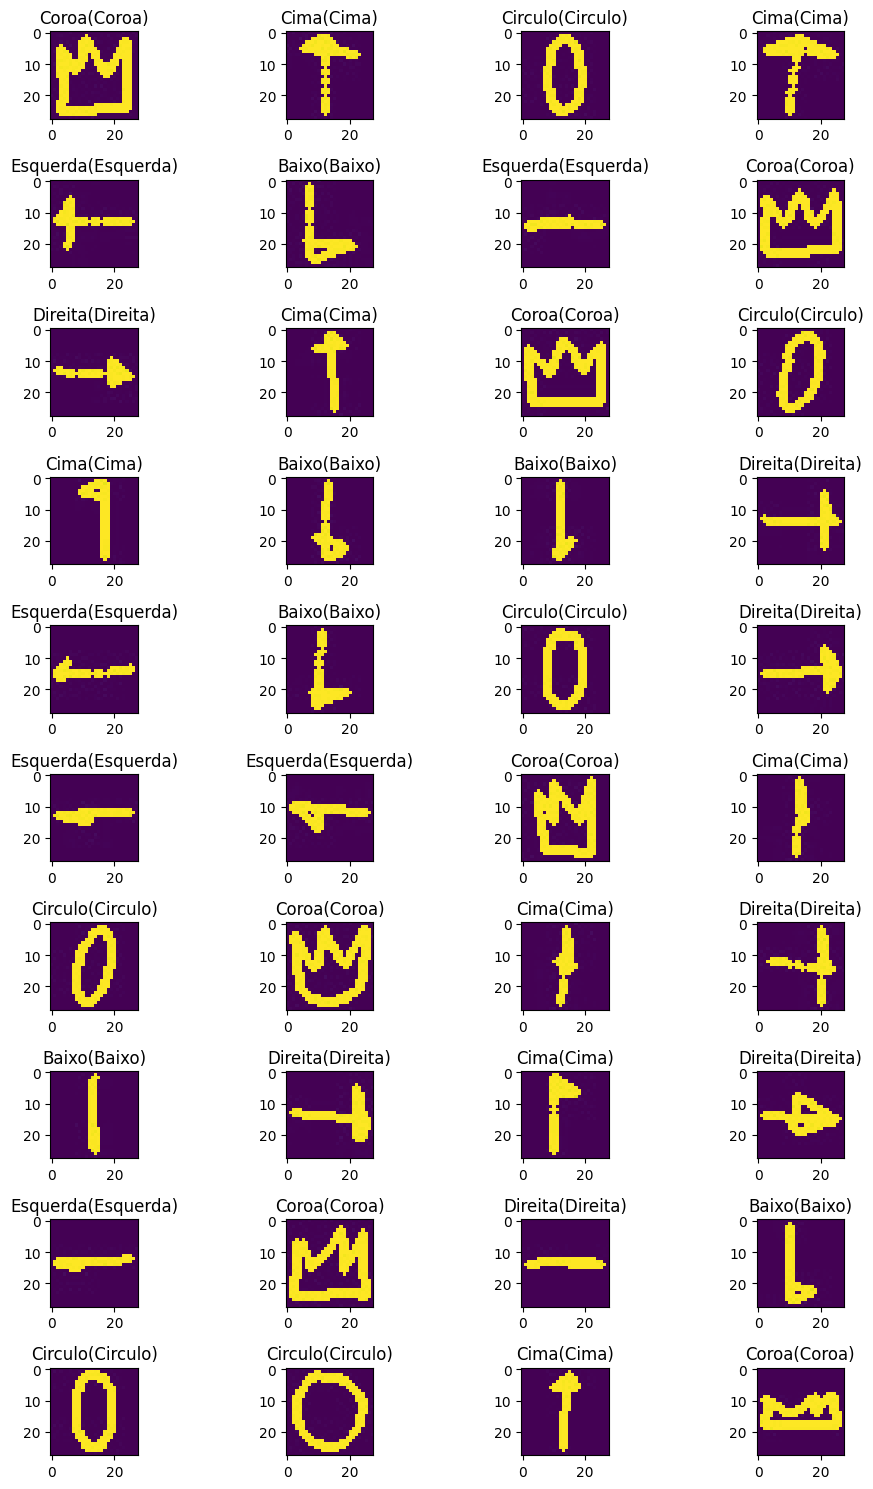

In [26]:
fig, ax = plt.subplots(10,4,figsize=(10,15))
for i in range(40):
    plt.subplot(10,4,i+1)
    plt.imshow(xs[i])
    match yhats[i]:
        case 0:
            name = "Baixo"
        case 1:
            name = "Cima"
        case 2:
            name = "Esquerda"
        case 3:
            name = "Direita"
        case 4:
            name = "Circulo"
        case 5:
            name = "Coroa"
    match ysArg[i]:
        case 0:
            Rname = "Baixo"
        case 1:
            Rname = "Cima"
        case 2:
            Rname = "Esquerda"
        case 3:
            Rname = "Direita"
        case 4:
            Rname = "Circulo"
        case 5:
            Rname = "Coroa"
    plt.title(f'{name}({Rname})')
fig.tight_layout()
plt.show()

In [27]:
print(f)

MyCNN(
  (conv1): Conv2d(1, 6, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(6, 18, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=648, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=50, bias=True)
  (fc3): Linear(in_features=50, out_features=6, bias=True)
  (R): ReLU()
)


In [28]:
torch.save(f.state_dict(), 'CNN2.pth')

In [ ]:
BoldTestImages = BoldTest_ds.x
BoldTestLables = BoldTest_ds.y
print(BoldTestImages.shape,BoldTestLables.shape)

acertos = 0
total = 5235
yResposta = np.zeros(shape=(5235))
BoldTestLablesArg = BoldTestLables.argmax(axis=1)

for i in range(5235):
    yResposta[i] = f(BoldTestImages[i].view(1,28,28)).argmax().item()
    if yResposta[i] == BoldTestLablesArg[i]:
        acertos += 1
    i += 1

precisao = (acertos/total)*100
print(f'Precisão da rede = {precisao}')

torch.Size([5235, 28, 28]) torch.Size([5235, 6])
tensor(1)
Precisão da rede = 99.65616045845273
